##  Advanced Data Augmentation with Keras 


170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 597s 4us/step


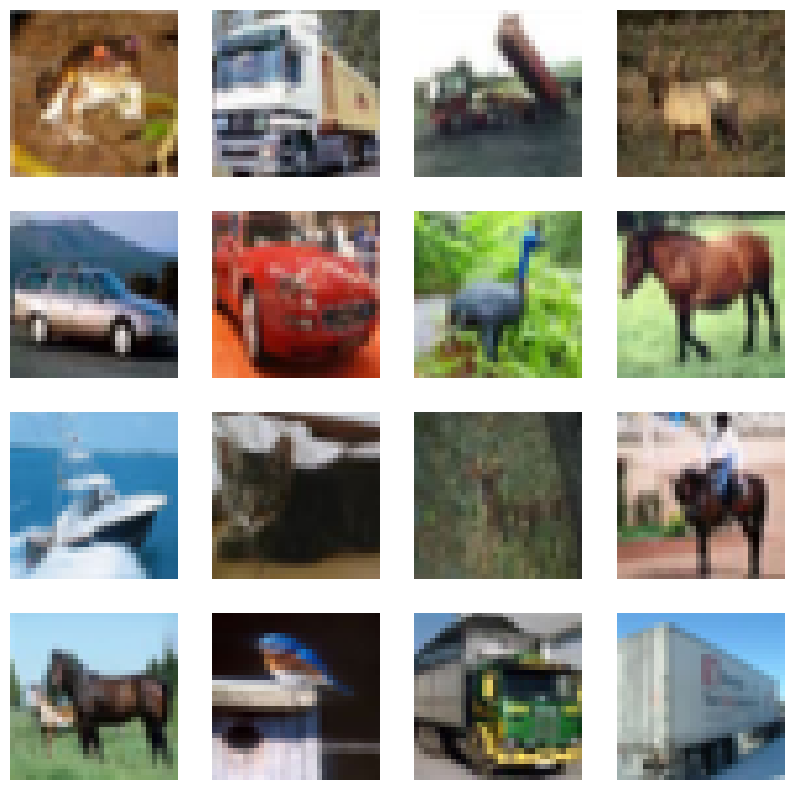

In [1]:

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Load CIFAR-10 dataset for training images
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

# Normalize the pixel values for augmentation
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# Display a sample of the training images
plt.figure(figsize=(10, 10))
for i in range(16):
    plt.subplot(4, 4, i+1)
    plt.imshow(x_train[i])
    plt.axis('off')
plt.show()


In [2]:
from PIL import Image, ImageDraw

# Create a blank white image
image = Image.new('RGB', (224, 224), color = (255, 255, 255))

# Draw a red square
draw = ImageDraw.Draw(image)
draw.rectangle([(50, 50), (174, 174)], fill=(255, 0, 0))

# Save the image
image.save('sample.jpg')


In [ ]:
import numpy as np 
import matplotlib.pyplot as plt 
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array 

# Load a sample image 
img_path = 'sample.jpg' 
img = load_img(img_path) 
x = img_to_array(img) 
x = np.expand_dims(x, axis=0) 

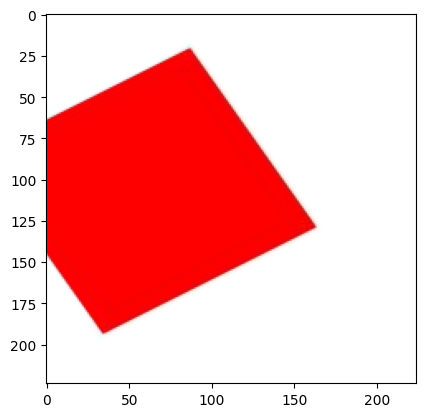

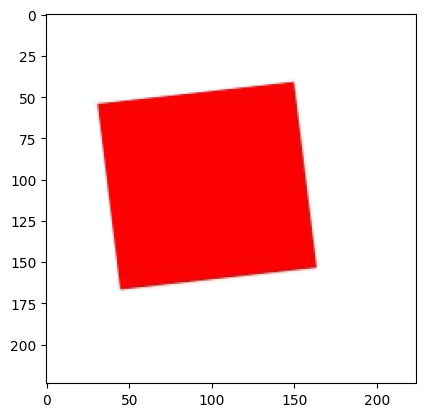

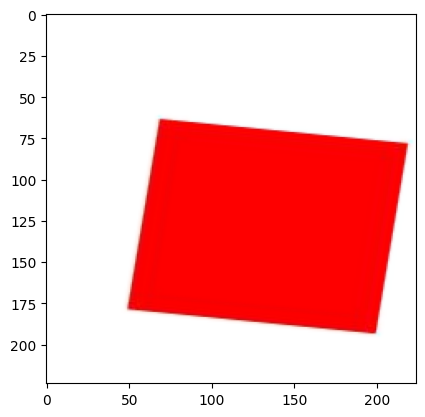

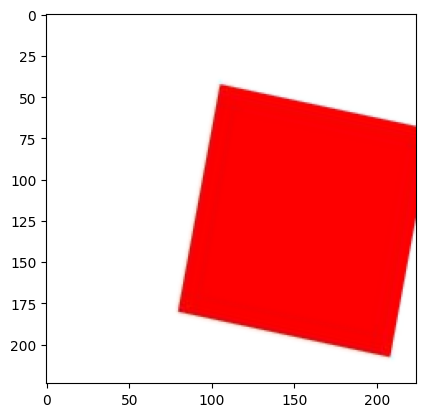

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array

# Load the sample image
img_path = 'sample.jpg'
img = load_img(img_path)
x = img_to_array(img)
x = np.expand_dims(x, axis=0)

# Create an instance of ImageDataGenerator with basic augmentations
datagen = ImageDataGenerator(
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

# Generate batches of augmented images
i = 0
for batch in datagen.flow(x, batch_size=1):
    plt.figure(i)
    imgplot = plt.imshow(batch[0].astype('uint8'))
    i += 1
    if i % 4 == 0:
        break

plt.show()



#### Feature-wise and sample-wise normalization 

Implement feature-wise and sample-wise normalization on the data set as follows:    


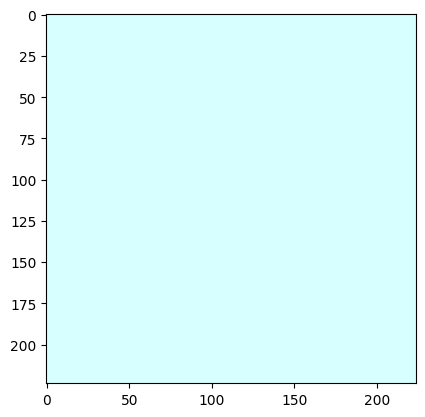

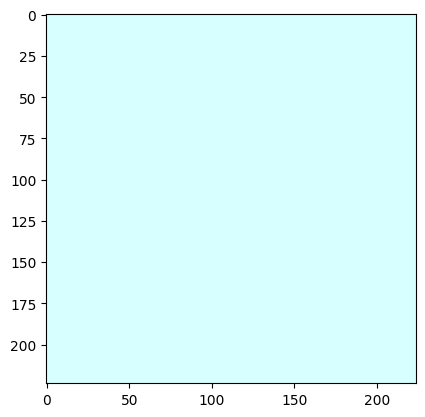

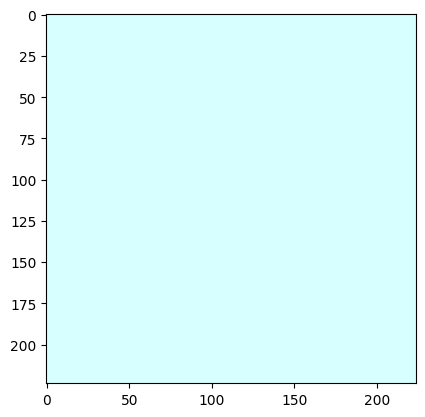

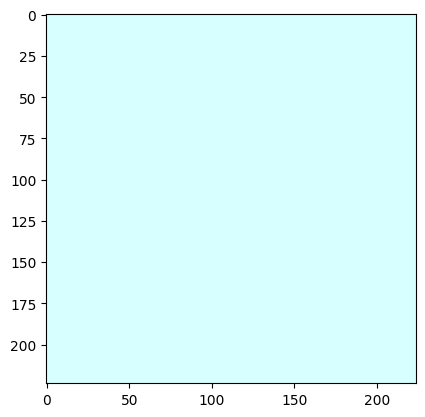

In [5]:
# Create an instance of ImageDataGenerator with normalization options
datagen = ImageDataGenerator(
    featurewise_center=True,
    featurewise_std_normalization=True,
    samplewise_center=True,
    samplewise_std_normalization=True
)

# Load the sample image again and fit the generator (normally done on the training set)
datagen.fit(x)

# Generate batches of normalized images
i = 0
for batch in datagen.flow(x, batch_size=1):
    plt.figure(i)
    imgplot = plt.imshow(batch[0].astype('uint8'))
    i += 1
    if i % 4 == 0:
        break

plt.show()




#### Step 4: Custom data augmentation function 

Next, you define and apply a custom augmentation function that adds random noise to images as follows: 


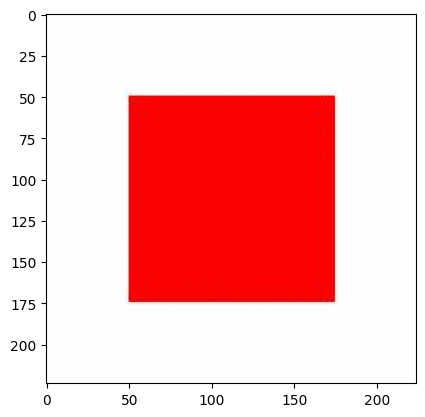

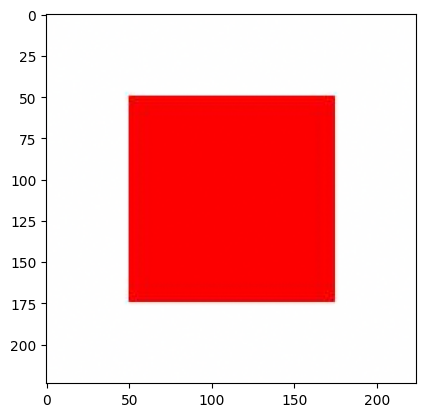

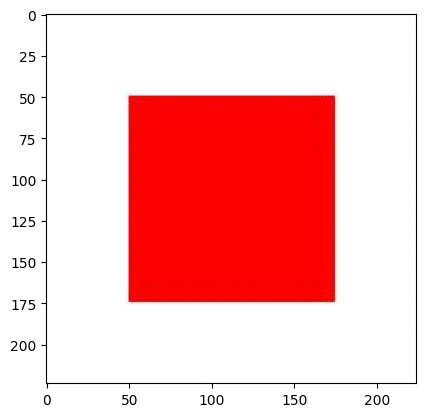

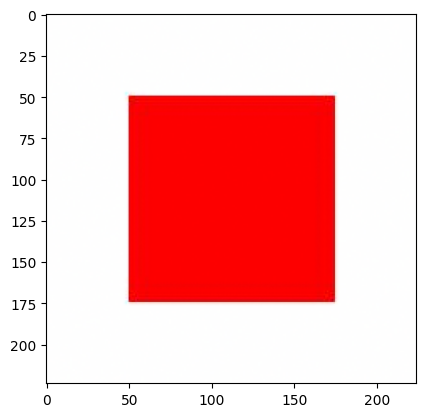

In [6]:
# Define a custom data augmentation function
def add_random_noise(image):
    noise = np.random.normal(0, 0.1, image.shape)
    return image + noise

# Create an instance of ImageDataGenerator with the custom augmentation
datagen = ImageDataGenerator(preprocessing_function=add_random_noise)

# Generate batches of augmented images with noise
i = 0
for batch in datagen.flow(x, batch_size=1):
    plt.figure(i)
    imgplot = plt.imshow(batch[0].astype('uint8'))
    i += 1
    if i % 4 == 0:
        break

plt.show()

#### Step 5: Visualize augmented images 

Visualize the augmented images to understand the impact of each augmentation technique. 


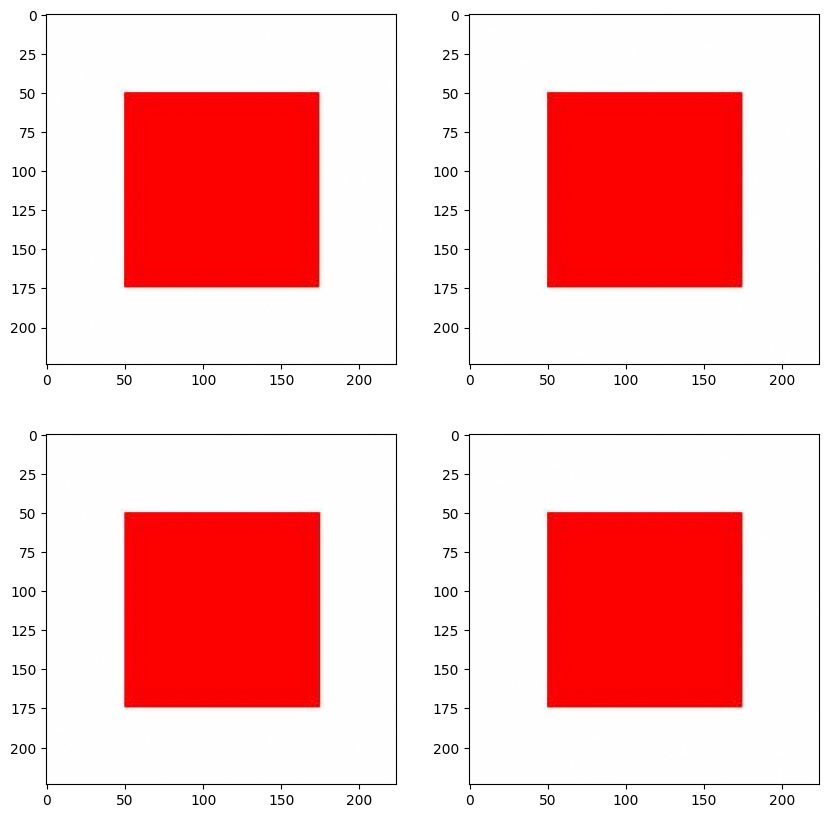

In [7]:

plt.figure(figsize=(10, 10))
for i, batch in enumerate(datagen.flow(x, batch_size=1)):
    if i >= 4: 
        break
    plt.subplot(2, 2, i+1)
    plt.imshow(batch[0].astype('uint8'))
plt.show()


Download the `sample_images` folder containing a collection of images that will be used for this practice exercise.


In [8]:
!wget https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/RgP3JFNtPTZA34UmG3KZaA/sample-images.zip

--2026-05-09 16:04:07--  https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/RgP3JFNtPTZA34UmG3KZaA/sample-images.zip
Resolving cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)... 169.45.118.108
Connecting to cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)|169.45.118.108|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 14868 (15K) [application/zip]
Saving to: ‘sample-images.zip’

sample-images.zip   100%[===================>]  14.52K  96.4KB/s    in 0.2s    

2026-05-09 16:04:09 (96.4 KB/s) - ‘sample-images.zip’ saved [14868/14868]



Extract the images by unzipping the folder


In [ ]:
!unzip sample-images.zip 

Archive:  sample-images.zip
   creating: sample_images/
  inflating: sample_images/training_images1.jpg  
  inflating: sample_images/training_images2.jpg  
  inflating: sample_images/training_images3.jpg  


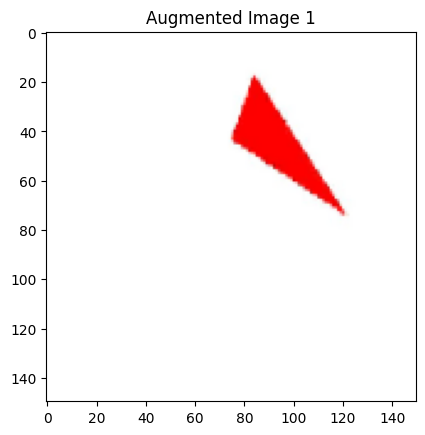

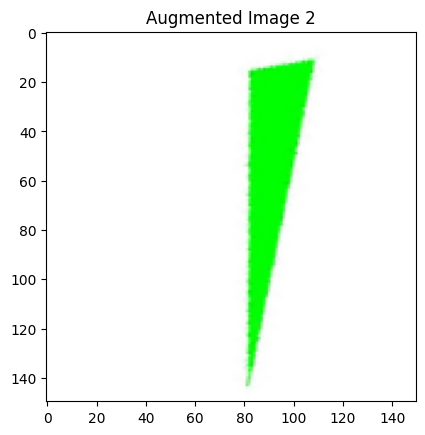

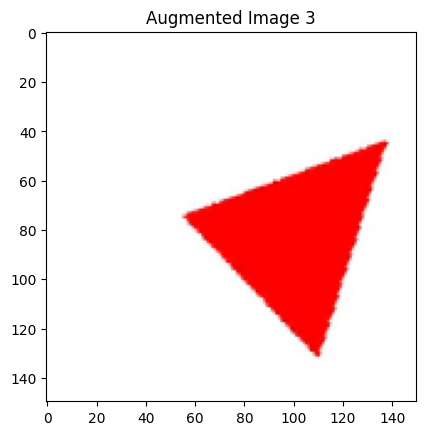

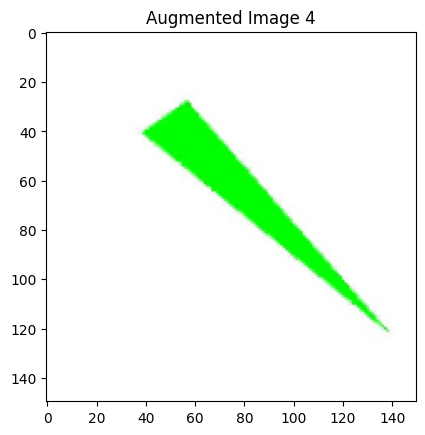

In [12]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
import matplotlib.pyplot as plt
import numpy as np

datagen = ImageDataGenerator(
    rotation_range=40,
    rescale=1.0/255.0,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest',
    shear_range=0.2,
    zoom_range=0.2
)

image_paths = [
    'sample_images/training_images1.jpg',
    'sample_images/training_images2.jpg',
    'sample_images/training_images3.jpg'
]

training_images = []
for image_path in image_paths:
    img = load_img(image_path, target_size=(150, 150))
    x = img_to_array(img)
    training_images.append(x)

training_images = np.array(training_images)
i = 0

for batch in datagen.flow(training_images, batch_size=10):
    plt.figure(i)
    plt.imshow(batch[0])
    plt.title(f'Augmented Image {i + 1}')  
    i += 1  
    if i % 4 == 0:  
        break  

plt.show()


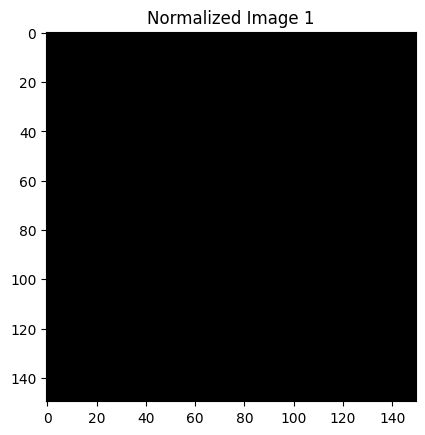

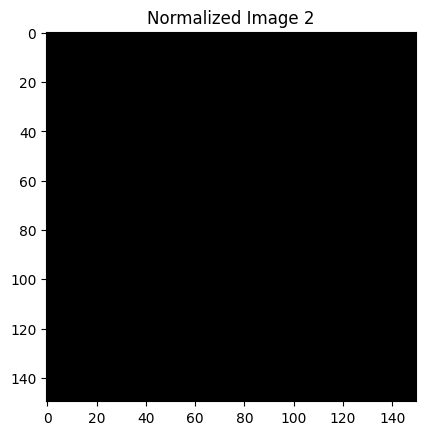

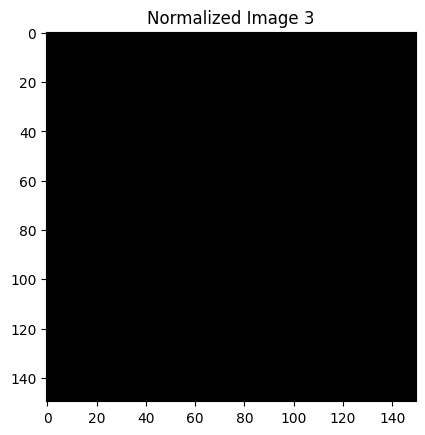

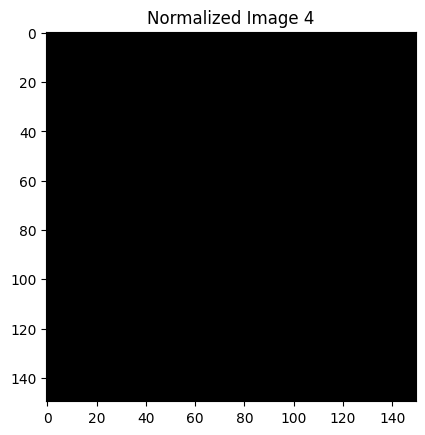

In [16]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt

datagen = ImageDataGenerator(
    featurewise_center=True,
    featurewise_std_normalization=True,
    samplewise_center=True,
    samplewise_std_normalization=True
)

datagen.fit(training_images)

i = 0
for batch in datagen.flow(training_images, batch_size=1):
    plt.figure(i)
    img_plot = plt.imshow(batch[0])
    plt.title(f'Normalized Image {i+1}')
    i += 1
    if i % 4 == 0:
        break

plt.show()


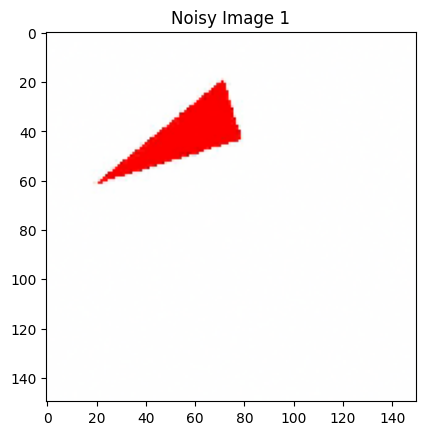

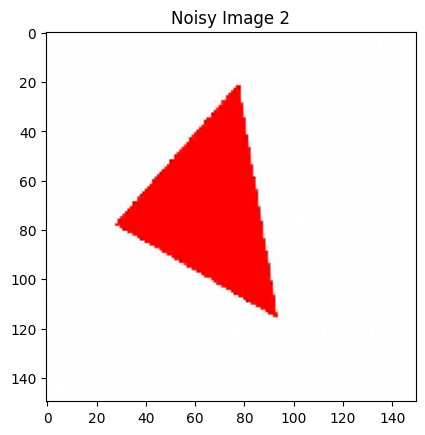

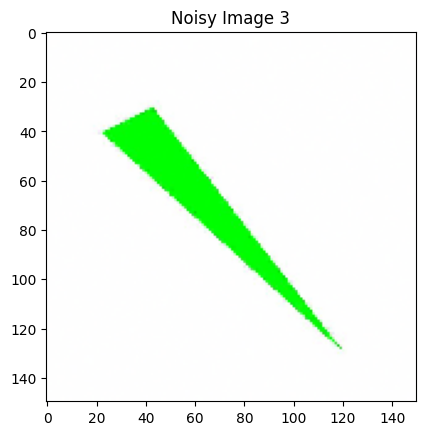

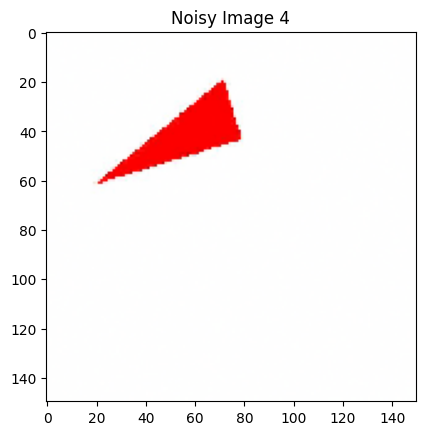

In [18]:
def add_noise(image):
    noise = np.random.normal(0, 0.1, image.shape)
    return image + noise

datagen = ImageDataGenerator(preprocessing_function=add_noise)

i = 0
for batch in datagen.flow(training_images, batch_size=1):
    plt.figure(i)
    plt.imshow(batch[0].astype('uint8'))
    plt.title(f'Noisy Image {i + 1}')  
    i += 1  
    if i % 4 == 0:  
        break  

plt.show()
